In [8]:
# ============================================================
# DECOMPOSIÇÃO DE SÉRIES TEMPORAIS
# Exemplo de modelo ADITIVO e MULTIPLICATIVO
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

# Para tornar o exemplo reproduzível
np.random.seed(42)

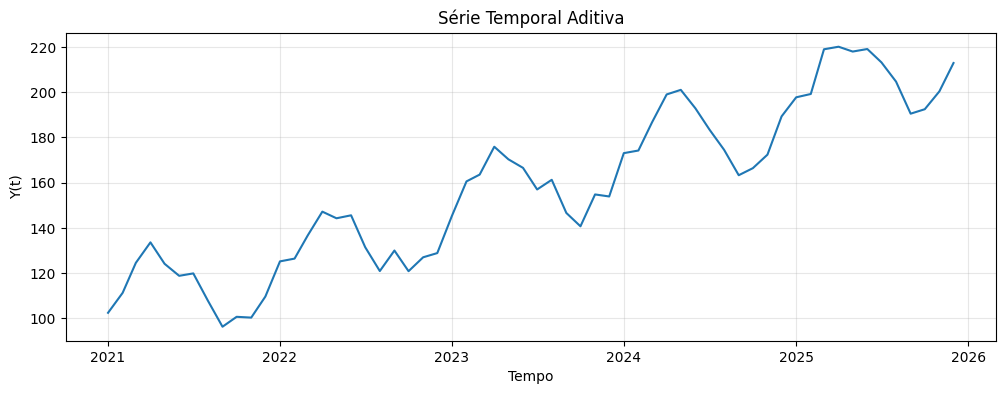

In [ ]:
# ============================================================
# 1. CRIAÇÃO DO EIXO TEMPORAL
# ============================================================

# 5 anos de dados mensais
n = 60

datas = pd.date_range(start="2021-01-01", periods=n, freq="MS")

t = np.arange(n)


# ============================================================
# 2. SÉRIE TEMPORAL ADITIVA
# ============================================================

# Tendência linear
tendencia_aditiva = 100 + 2 * t

# Componente sazonal com amplitude aproximadamente constante
sazonal_aditiva = 20 * np.sin(2 * np.pi * t / 12)

# Ruído aleatório
ruido_aditivo = np.random.normal(loc=0, scale=5, size=n)

# Modelo:
# Y(t) = Tendência + Sazonalidade + Ruído

serie_aditiva = tendencia_aditiva + sazonal_aditiva + ruido_aditivo

serie_aditiva = pd.Series(serie_aditiva, index=datas, name="Série Aditiva")


# ============================================================
# 3. VISUALIZAÇÃO DA SÉRIE ADITIVA
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(serie_aditiva)

plt.title("Série Temporal Aditiva")
plt.xlabel("Tempo")
plt.ylabel("Y(t)")
plt.grid(alpha=0.3)

plt.show()

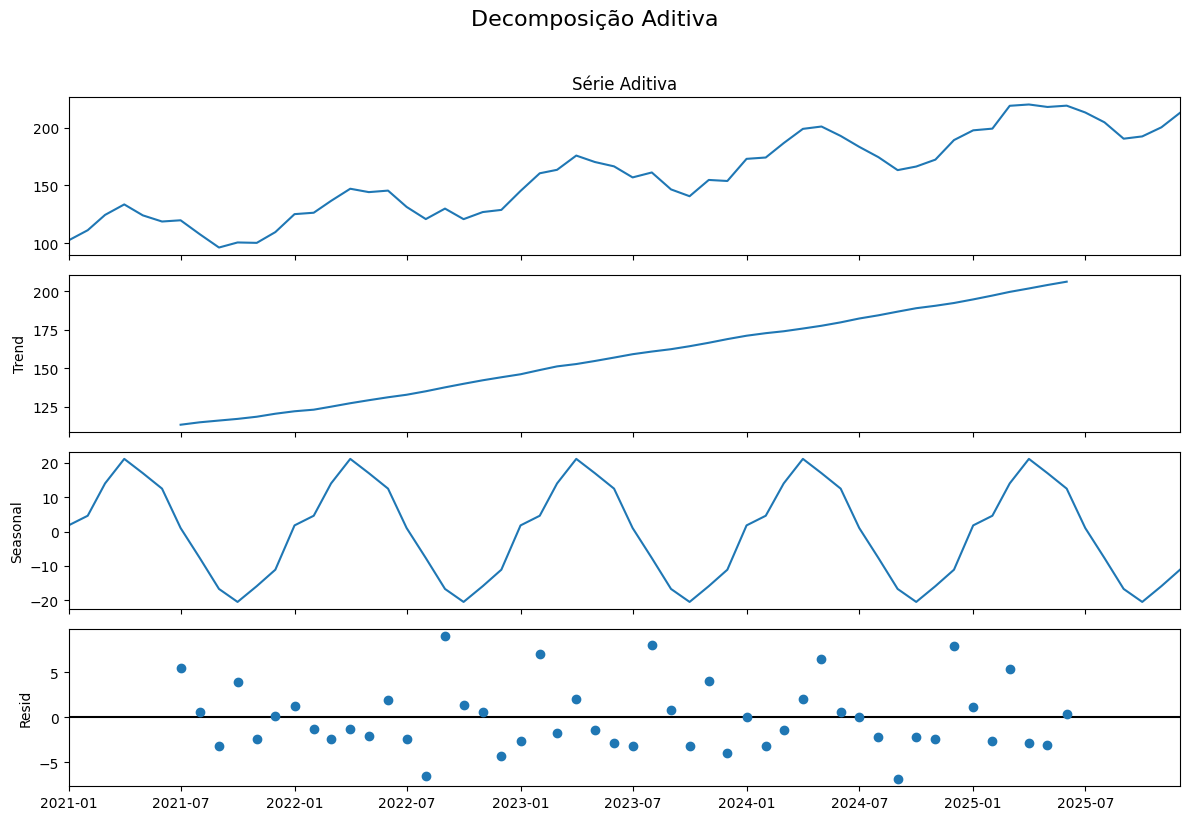

In [ ]:
# ============================================================
# 4. DECOMPOSIÇÃO ADITIVA
# ============================================================

decomp_aditiva = seasonal_decompose(serie_aditiva, model="additive", period=12)

fig = decomp_aditiva.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Decomposição Aditiva", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

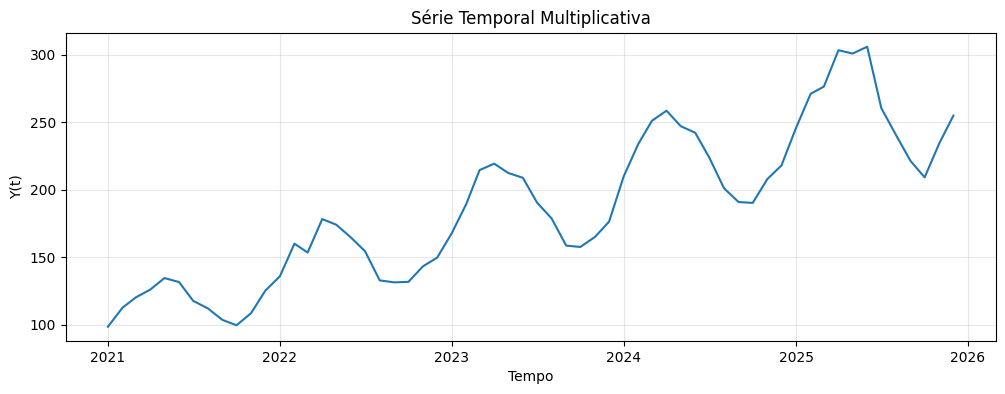

In [ ]:
# ============================================================
# 5. SÉRIE TEMPORAL MULTIPLICATIVA
# ============================================================

# Tendência crescente
tendencia_mult = 100 + 3 * t

# Fator sazonal
# Oscila aproximadamente entre 0.80 e 1.20

sazonal_mult = 1 + 0.20 * np.sin(2 * np.pi * t / 12)

# Ruído multiplicativo
ruido_mult = np.random.normal(loc=1, scale=0.03, size=n)

# Modelo:
# Y(t) = Tendência × Sazonalidade × Ruído

serie_multiplicativa = tendencia_mult * sazonal_mult * ruido_mult

serie_multiplicativa = pd.Series(
    serie_multiplicativa, index=datas, name="Série Multiplicativa"
)


# ============================================================
# 6. VISUALIZAÇÃO DA SÉRIE MULTIPLICATIVA
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(serie_multiplicativa)

plt.title("Série Temporal Multiplicativa")
plt.xlabel("Tempo")
plt.ylabel("Y(t)")
plt.grid(alpha=0.3)

plt.show()

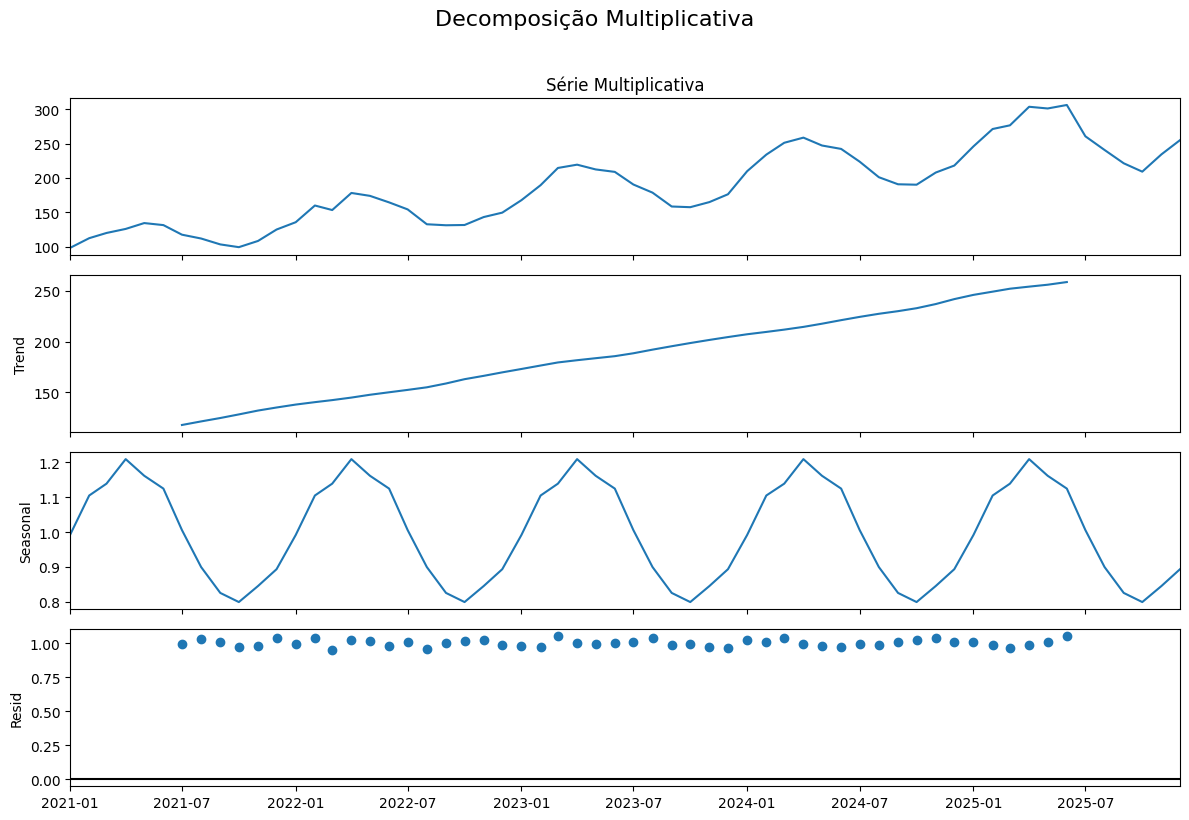

In [ ]:
# ============================================================
# 7. DECOMPOSIÇÃO MULTIPLICATIVA
# ============================================================

decomp_mult = seasonal_decompose(
    serie_multiplicativa, model="multiplicative", period=12
)

fig = decomp_mult.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Decomposição Multiplicativa", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 8. COMPARANDO AS COMPONENTES SAZONAIS
# ============================================================

print("Componente sazonal - modelo aditivo:")
print(decomp_aditiva.seasonal.head(12))

print("\nComponente sazonal - modelo multiplicativo:")
print(decomp_mult.seasonal.head(12))

Componente sazonal - modelo aditivo:
2021-01-01     1.774139
2021-02-01     4.575246
2021-03-01    13.962796
2021-04-01    21.087412
2021-05-01    16.939501
2021-06-01    12.449441
2021-07-01     1.007594
2021-08-01    -7.709219
2021-09-01   -16.680937
2021-10-01   -20.450352
2021-11-01   -15.864933
2021-12-01   -11.090687
Freq: MS, Name: seasonal, dtype: float64

Componente sazonal - modelo multiplicativo:
2021-01-01    0.991714
2021-02-01    1.104860
2021-03-01    1.138861
2021-04-01    1.209180
2021-05-01    1.161497
2021-06-01    1.124686
2021-07-01    1.005712
2021-08-01    0.899726
2021-09-01    0.825529
2021-10-01    0.799347
2021-11-01    0.845330
2021-12-01    0.893557
Freq: MS, Name: seasonal, dtype: float64


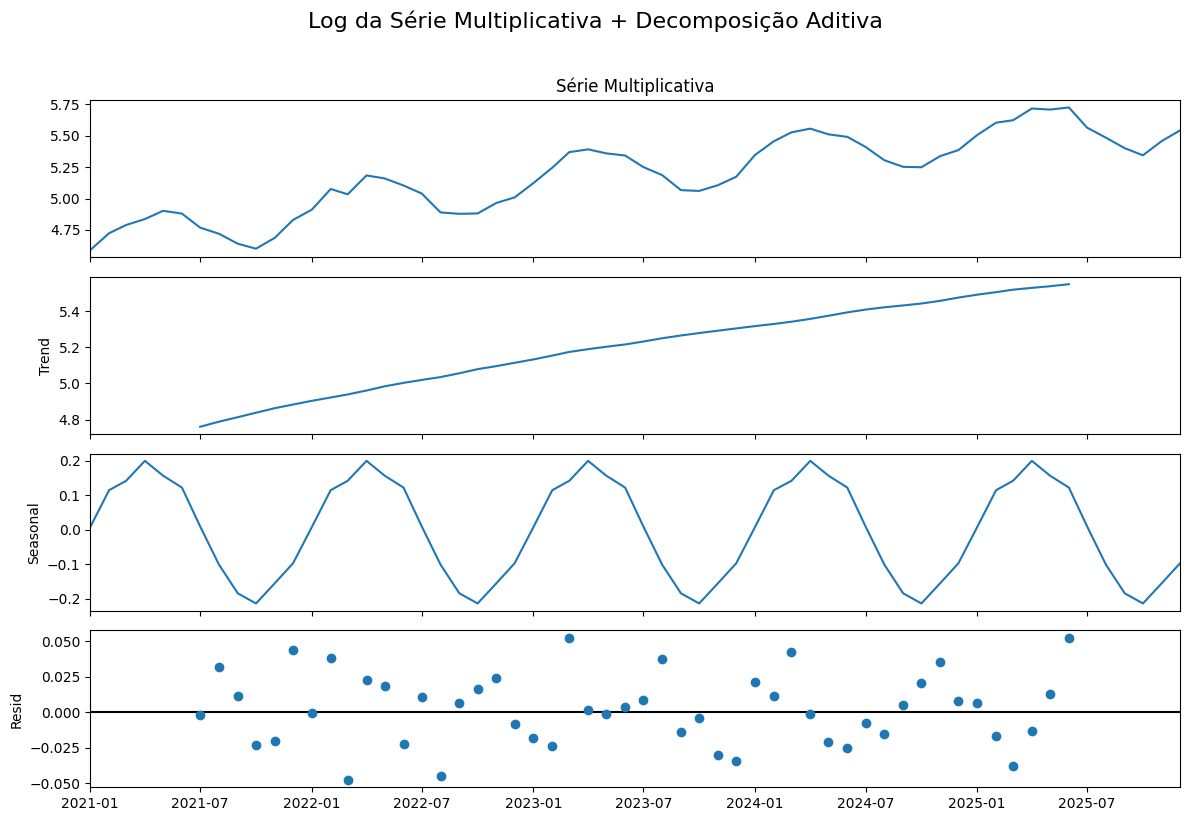

In [ ]:
# ============================================================
# 9. TRANSFORMAÇÃO LOGARÍTMICA
# ============================================================

serie_log = np.log(serie_multiplicativa)

decomp_log = seasonal_decompose(serie_log, model="additive", period=12)

fig = decomp_log.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Log da Série Multiplicativa + Decomposição Aditiva", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()